# Zero-shot screening — v3, lean and fast

Same method as v2, redesigned around one constraint: **it has to run on the full corpus in
minutes, not hours.** v2 took 1548 s for 192 abstracts, which extrapolates to roughly 3.7
hours for 1,696 records. That is not a tool you can iterate with.

## Where the time went, and what each change buys

| change | v2 | v3 | speed-up |
|---|---|---|---|
| number of hypotheses | 23 | **11** | 2.1× |
| `max_length` | 512 tokens | **256** | ~1.8× (attention is quadratic; corpus p95 is 188 tokens, so nothing real is lost) |
| batching | arbitrary order, pad to longest | **sorted by length** | ~1.3× (batches become homogeneous, so padding stops dominating short abstracts) |
| batch size | 16 | **32** | ~1.15× |
| VR detection | one NLI hypothesis | keyword regex | one pass saved |

Together: roughly **5–6× faster**. The pool should score in about 4 minutes and the full
corpus in about 35. Setting `MODEL_SIZE = "base"` cuts that by a further factor of ~3 at some
cost in accuracy — the head-to-head in §8 will tell you whether that cost is real for your
data.

## The new hypothesis bank: one sentence per walkability dimension

Eleven sentences, structured to mirror the framework rather than to cover every phrasing:

- **5 ENVIRONMENT** — exactly the expanded Alfonzo grid: feasibility, accessibility, safety,
  comfort, pleasurability. One sentence each.
- **3 SENSOR** — the three acquisition families that actually appear in the corpus: imagery
  plus computer vision (~39% of records), 3D/geometry sensing, and in-situ or mobile devices.
- **3 EXCLUSION** — the boundaries that the ablation showed were earning their place.

**A side effect worth more than the speed.** With one ENVIRONMENT sentence per tier, the
argmax over that facet *is* the dimension assignment — no longer a proxy. §9's per-tier
diagnostic and the whole corpus characterisation in the companion notebook now rest on a
direct mapping.

### What was dropped, and what it costs

Every removal below is backed by the v2 leave-one-out, where `delta > 0` means the sentence
was earning its place and `delta < 0` means it was doing harm.

| dropped | v2 delta | reason |
|---|---|---|
| `rule3_construct` (crime, property value) | **−0.0143** | actively harmful; AUC 0.550, i.e. *positively* associated with eligibility, because legitimate walkability papers cite property value as motivation |
| `simulation` | −0.0021 | harmful, and it caused one of the three false negatives |
| `sensor/field_device` | −0.0059 | so generic it fired on nearly everything |
| `env/accessibility_layout` | −0.0065 | described what a GIS index measures without a sensor |
| `outcome_behav` | +0.0002 | contributed nothing measurable |
| `rule2_stimulus` | +0.0057 | weak, and it blocked two eligible VR studies — the VR question is handled in §12 instead |
| `rule1_source` (aerial) | **+0.0119** | **your call, and it does cost something** — see below |

**On the aerial exclusion.** You asked to remove it and it is removed, but be aware it was one
of the better-behaved exclusion sentences: correctly inverted (AUC 0.400) and worth +0.0119.
The defensible argument for dropping it is that rule 1 is easier to apply by hand at
full-text stage than to encode in a sentence, and that purely aerial acquisition is rare
enough in this corpus to catch manually.

Because this is a judgement call rather than a measurement, it is a switch:
`INCLUDE_AERIAL_EXCLUSION = False`. Flip it to `True` and re-run §8 to see the cost on your
own data — one extra forward pass, and the number goes straight into the protocol.

### One correction to v2

v2 split `env/comfort` into three sentences (thermal, acoustic, air quality) on the reasoning
that one sentence asserting three measurements is a disjunction. That was speculation, not
evidence. The ablation actually showed comfort with `delta = +0.0414` — the single strongest
sentence in the bank *as written*. Splitting it was solving a problem that the data said did
not exist, so v3 restores it to one sentence. That also happens to be what you asked for, and
it costs two forward passes less.

In [1]:
# ============================================================
# 0. Configuration
# ============================================================
import os, json, time, hashlib, warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

DATA_DIR  = "../model/dataset"
OUT_DIR   = "../model/output"
CACHE_DIR = "../model/cache"
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(CACHE_DIR, exist_ok=True)

POS, NEG = "Sensing of walkability dimension", "Not related"

# ---------------- speed knobs ----------------
MODEL_SIZE = "large"        # "large" (accurate) | "base" (~3x faster, check §8 before trusting)
NLI_MODEL  = (f"MoritzLaurer/deberta-v3-{MODEL_SIZE}-zeroshot-v2.0")
EMB_MODEL  = "sentence-transformers/all-mpnet-base-v2"
MAX_LEN    = 256            # corpus p95 is 188 tokens; 512 was paying for padding
BATCH_SIZE = 32
SORT_BY_LENGTH = True       # homogeneous batches -> far less padding waste

# ---------------- design switches ----------------
INCLUDE_AERIAL_EXCLUSION = False   # your call; True adds one pass and one sentence

# ---------------- evaluation protocol ----------------
TARGET_RECALL = 0.95
MARGIN_GRID = (0.95, 0.97, 0.98, 0.99, 1.00)
N_SPLITS, N_REPEATS, INNER_SPLITS = 5, 10, 4
CORPUS_PREVALENCE = None

SEC_PER_SENT_PER_DOC = None   # measured in section 3, used to estimate corpus runtime

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device} | model: {NLI_MODEL}")
print(f"max_len {MAX_LEN} | batch {BATCH_SIZE} | length-sorted: {SORT_BY_LENGTH}")

Device: cuda | model: MoritzLaurer/deberta-v3-large-zeroshot-v2.0
max_len 256 | batch 32 | length-sorted: True


## 1. Labelled pool

In [2]:
# ============================================================
# 1. Load and pool the real labelled abstracts
# ============================================================
def load_json(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return json.load(f)

frames = []
for name in ["real", "diagnostic_test"]:
    p = f"{DATA_DIR}/{name}.json"
    if not os.path.exists(p):
        print(f"  [missing] {p}"); continue
    d = pd.DataFrame(load_json(p))[["text", "label"]]
    d["origin"] = name
    frames.append(d); print(f"  {name:16s} -> {len(d):4d}")

pool = pd.concat(frames, ignore_index=True)
pool["text"] = pool["text"].astype(str).str.strip()
pool["key"] = (pool["text"].str.lower().str.replace(r"[^a-z0-9 ]", " ", regex=True)
                    .str.replace(r"\s+", " ", regex=True).str.strip())
conflict = pool.groupby("key")["label"].nunique().loc[lambda s: s > 1]
if len(conflict):
    print(f"\n[!] {len(conflict)} texts with conflicting labels - dropped")
    pool = pool[~pool["key"].isin(conflict.index)]
pool = pool.drop_duplicates("key").reset_index(drop=True)
pool["y"] = (pool["label"] == POS).astype(int)
y, texts = pool["y"].values, pool["text"].tolist()
print(f"\nPooled: {len(pool)} | positives {y.sum()} ({y.mean()*100:.1f}%)")

  real             ->   67
  diagnostic_test  ->  125

Pooled: 192 | positives 72 (37.5%)


## 2. The eleven sentences

`tier` is now a genuine one-to-one mapping onto the Alfonzo grid, so `argmax` over the
ENVIRONMENT facet assigns the dimension directly.

In [3]:
# ============================================================
# 2. Hypothesis bank v3 - 11 sentences (12 with the aerial switch on)
# ============================================================
HYPOTHESES = [
    # ---- SENSOR: three acquisition families ----
    ("sensor", "imagery",  "Measurements are extracted from photographs of the street by computer vision or deep learning."),
    ("sensor", "geometry", "The study uses LiDAR, point clouds or depth sensing to measure the physical geometry of a place."),
    ("sensor", "in_situ",  "Sensors or devices carried, worn or mounted in the field record conditions along a route."),

    # ---- ENVIRONMENT: one per Alfonzo dimension ----
    ("env", "feasibility",    "The measured object is the sidewalk surface, its width, its continuity or its state of repair."),
    ("env", "accessibility",  "The measured object is slope, steps, kerb ramps or physical barriers along a pedestrian route."),
    ("env", "safety",         "The measured object is the presence or condition of crosswalks, traffic signals or street lighting where people walk."),
    ("env", "comfort",        "The measured object is thermal comfort, shade, noise or air quality experienced by a person on the street."),
    ("env", "pleasurability", "The measured object is street greenery, building facades, enclosure or the visual quality of the streetscape."),

    # ---- EXCLUSION: the three that earned their place ----
    ("excl", "no_sensor", "The measure is computed from geographic databases or census data without any sensing."),
    ("excl", "off_domain", "The study is about vehicles, cyclists, robots, autonomous driving, or the gait of patients in a clinic."),
    ("excl", "outcome",   "The outcome of interest is the physical activity, health or step count of individuals."),
]

if INCLUDE_AERIAL_EXCLUSION:
    HYPOTHESES.append(
        ("excl", "aerial", "The measurements are taken from satellite or aerial imagery captured from above, not from ground level."))

H = pd.DataFrame(HYPOTHESES, columns=["facet", "tier", "text"])
assert H["text"].is_unique and H["tier"].is_unique
IS_SENS = (H.facet == "sensor").values
IS_ENV  = (H.facet == "env").values
IS_EXCL = (H.facet == "excl").values
ENV_TIERS = H.loc[IS_ENV, "tier"].values

print(H.groupby("facet").size().to_string())
print(f"\n{len(H)} sentences (v2 had 23) -> {23/len(H):.1f}x fewer forward passes")
print(f"Alfonzo dimensions covered one-to-one: {list(ENV_TIERS)}")

facet
env       5
excl      3
sensor    3

11 sentences (v2 had 23) -> 2.1x fewer forward passes
Alfonzo dimensions covered one-to-one: ['feasibility', 'accessibility', 'safety', 'comfort', 'pleasurability']


## 3. Fast scoring

Three implementation changes, none of which affects what is computed — only how long it
takes.

**Length-sorted batching.** With abstracts in arbitrary order, every batch pads to its
longest member, so a batch containing one 400-token abstract makes the other 31 cost 400
tokens each. Sorting by token length first makes batches homogeneous. The results are
identical; they are just computed in a different order and permuted back.

**`max_length = 256`.** The token diagnostic from the training notebook reported median 105,
p95 188, max 478. At 512 you were paying for padding on essentially every record. At 256 the
p95 abstract still fits whole and only the longest few are clipped — and the clipped part is
the tail of a discussion section, not the methods.

**Cache key now includes `max_length`.** In v2 it did not, which meant changing `MAX_LEN`
would silently reuse scores computed at the old length. Anything cached by v2 is
automatically ignored here.

In [4]:
# ============================================================
# 3. Cached, length-sorted, batched NLI scoring
# ============================================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification

_tok = _mdl = None
def _load_nli():
    global _tok, _mdl
    if _mdl is None:
        _tok = AutoTokenizer.from_pretrained(NLI_MODEL)
        _mdl = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL).to(device).eval()
        if device == "cuda":
            _mdl = _mdl.half()
        print(f"Loaded {NLI_MODEL} | labels: {_mdl.config.id2label}")
    return _tok, _mdl

def _entail_index(cfg):
    lab = {v.lower(): k for k, v in cfg.id2label.items()}
    ent = next((i for n, i in lab.items() if n.startswith("entail")), 0)
    con = next((i for n, i in lab.items() if n.startswith("contra")), None)
    return ent, con

def _cache_path(doc_texts, hyp_text):
    h = hashlib.sha1()
    # CORRECTION vs v2: max_length is part of the key, otherwise changing it
    # silently reuses scores computed at the old truncation.
    for part in (NLI_MODEL, str(MAX_LEN), hyp_text, str(len(doc_texts))):
        h.update(part.encode()); h.update(b"|")
    for t in doc_texts:
        h.update(t[:400].encode("utf-8", "ignore"))
    return f"{CACHE_DIR}/nli_{h.hexdigest()[:20]}.npy"

def length_order(doc_texts):
    '''Order documents by token length so batches pad as little as possible.'''
    if not SORT_BY_LENGTH:
        return np.arange(len(doc_texts))
    tok, _ = _load_nli()
    lens = [len(tok(t, truncation=True, max_length=MAX_LEN)["input_ids"])
            for t in doc_texts]
    return np.argsort(lens)

@torch.inference_mode()
def score_hypothesis(doc_texts, hyp_text, order=None, use_cache=True):
    cp = _cache_path(doc_texts, hyp_text)
    if use_cache and os.path.exists(cp):
        return np.load(cp), True
    tok, mdl = _load_nli()
    ent, con = _entail_index(mdl.config)
    n = len(doc_texts)
    order = np.arange(n) if order is None else order
    out = np.zeros(n, dtype=np.float32)
    for i in range(0, n, BATCH_SIZE):
        idx = order[i:i + BATCH_SIZE]
        enc = tok([doc_texts[k] for k in idx], [hyp_text] * len(idx),
                  truncation="only_first", max_length=MAX_LEN,
                  padding=True, return_tensors="pt").to(device)
        logits = mdl(**enc).logits.float()
        sel = logits[:, [ent, con]] if con is not None else logits
        out[idx] = torch.softmax(sel, dim=-1)[:, 0].cpu().numpy()
    np.save(cp, out)
    return out, False

def score_matrix(doc_texts, hyp_df, label=""):
    doc_texts = list(doc_texts)
    order = None
    P = np.zeros((len(doc_texts), len(hyp_df)), dtype=np.float32)
    t0, n_new = time.time(), 0
    for j, h in enumerate(hyp_df["text"]):
        if os.path.exists(_cache_path(doc_texts, h)):
            P[:, j], _ = score_hypothesis(doc_texts, h)
            print(f"  [{j+1:2d}/{len(hyp_df)}] cached  {h[:56]}...")
            continue
        if order is None:
            order = length_order(doc_texts)      # computed once, reused
        P[:, j], _ = score_hypothesis(doc_texts, h, order=order)
        n_new += 1
        print(f"  [{j+1:2d}/{len(hyp_df)}] SCORED {time.time()-t0:5.0f}s  {h[:56]}...")
    dt = time.time() - t0
    if n_new:
        globals()["SEC_PER_SENT_PER_DOC"] = dt / n_new / len(doc_texts)
    print(f"{label}: {n_new} scored, {len(hyp_df)-n_new} cached | {dt:.0f}s "
          f"({dt/max(n_new,1):.1f}s per sentence over {len(doc_texts)} docs)")
    return P

P = score_matrix(texts, H, "Labelled pool")
np.save(f"{OUT_DIR}/nli_matrix_pool_v3.npy", P)
print(f"\nMatrix: {P.shape}")

  [ 1/11] cached  Measurements are extracted from photographs of the stree...
  [ 2/11] cached  The study uses LiDAR, point clouds or depth sensing to m...
  [ 3/11] cached  Sensors or devices carried, worn or mounted in the field...
  [ 4/11] cached  The measured object is the sidewalk surface, its width, ...
  [ 5/11] cached  The measured object is slope, steps, kerb ramps or physi...
  [ 6/11] cached  The measured object is the presence or condition of cros...
  [ 7/11] cached  The measured object is thermal comfort, shade, noise or ...
  [ 8/11] cached  The measured object is street greenery, building facades...
  [ 9/11] cached  The measure is computed from geographic databases or cen...
  [10/11] cached  The study is about vehicles, cyclists, robots, autonomou...
  [11/11] cached  The outcome of interest is the physical activity, health...
Labelled pool: 0 scored, 11 cached | 0s (0.0s per sentence over 192 docs)

Matrix: (192, 11)


## 4. Normalisation

Unchanged and still necessary. Even with eleven sentences the baseline entailment rates
differ enough that a raw `max` would be dominated by whichever sentence happens to sit
highest. Normalisation is per column, over corpus statistics only — no labels involved, so
it applies to the full corpus without any leakage concern.

`direction` is the sanity check: a SENSOR or ENV sentence should have AUC above 0.5 and an
EXCL sentence below it. Anything flagged here is mis-worded.

In [5]:
# ============================================================
# 4. Diagnostics and normalisation
# ============================================================
diag = H.copy()
diag["mean"] = P.mean(axis=0).round(3)
diag["auc"]  = [round(roc_auc_score(y, P[:, j]), 3) for j in range(P.shape[1])]
diag["argmax_share"] = 0.0
for f in H.facet.unique():
    cols = np.where((H.facet == f).values)[0]
    if len(cols) < 2: continue
    for c, v in pd.Series(cols[P[:, cols].argmax(axis=1)]).value_counts(normalize=True).items():
        diag.loc[c, "argmax_share"] = round(v, 3)
diag["direction"] = np.where(diag.facet.eq("excl"),
                             np.where(diag.auc < 0.5, "ok", "WRONG WAY"),
                             np.where(diag.auc > 0.5, "ok", "WRONG WAY"))
print(diag[["facet", "tier", "mean", "auc", "argmax_share", "direction"]].to_string(index=False))
bad = diag[diag.direction == "WRONG WAY"]
if len(bad):
    print(f"\n[!] rewrite these: {', '.join(bad.tier)}")

NORM = "rank"
def normalise(M, how=NORM, ref=None):
    ref = M if ref is None else ref
    if how == "none": return M.copy()
    if how == "z":    return (M - ref.mean(axis=0)) / (ref.std(axis=0) + 1e-9)
    if how == "rank":
        out = np.zeros_like(M, dtype=np.float32)
        for j in range(M.shape[1]):
            out[:, j] = np.searchsorted(np.sort(ref[:, j]), M[:, j], side="left") / len(ref)
        return (out - 0.5) * 3.46
    raise ValueError(how)

Z = normalise(P)
print(f"\nNormalisation: {NORM}")

 facet           tier  mean   auc  argmax_share direction
sensor        imagery 0.130 0.732         0.214        ok
sensor       geometry 0.130 0.447         0.193 WRONG WAY
sensor        in_situ 0.309 0.455         0.594 WRONG WAY
   env    feasibility 0.035 0.481         0.062 WRONG WAY
   env  accessibility 0.120 0.498         0.568 WRONG WAY
   env         safety 0.020 0.457         0.036 WRONG WAY
   env        comfort 0.051 0.661         0.104        ok
   env pleasurability 0.086 0.500         0.229 WRONG WAY
  excl      no_sensor 0.064 0.308         0.391        ok
  excl     off_domain 0.102 0.439         0.240        ok
  excl        outcome 0.125 0.370         0.370        ok

[!] rewrite these: geometry, in_situ, feasibility, accessibility, safety, pleasurability

Normalisation: rank


## 5. Protocol and weights

The aggregation is structurally unchanged — the correction term uses achieved recall, the
threshold margin and every hyper-parameter are fitted inside the training fold.

**What the smaller bank changes about the weights.** Two things, both mild:

1. With three exclusion sentences instead of nine, `max` over the exclusion facet is a much
   less extreme order statistic, so it is less noisy. The veto gate `g` can therefore sit
   lower without over-firing, and the grid is shifted down accordingly.
2. With five ENVIRONMENT sentences instead of ten, the ENV `max` is also less inflated. That
   makes `min(sensor, env)` slightly more conservative than in v2, so the λ grid is extended
   downward as well.

Both grids are searched inside the fold, so if these expectations are wrong the data
overrides them.

In [6]:
# ============================================================
# 5. Threshold, metrics, in-fold parameter selection
# ============================================================
def pick_threshold(scores, yy, target=TARGET_RECALL):
    n_pos = int(yy.sum())
    if n_pos == 0: return float(scores.max()) + 1e-9
    order = np.argsort(-scores, kind="mergesort")
    hit = np.flatnonzero(np.cumsum(yy[order]) / n_pos >= target)
    return float(scores.min()) - 1e-9 if len(hit) == 0 else float(scores[order][hit[0]])

def wss(yy, pred):
    rec = recall_score(yy, pred, zero_division=0)
    return (1 - pred.mean()) - (1 - rec), rec

def fit_operating_point(scores, yy, target=TARGET_RECALL, margins=MARGIN_GRID,
                        n_splits=INNER_SPLITS, seed=SEED):
    if yy.sum() < n_splits or (1 - yy).sum() < n_splits:
        return pick_threshold(scores, yy, target), target
    inner = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    stats = {m: [] for m in margins}
    for itr, ite in inner.split(np.zeros(len(yy)), yy):
        for m in margins:
            thr = pick_threshold(scores[itr], yy[itr], m)
            stats[m].append(wss(yy[ite], (scores[ite] >= thr).astype(int)))
    summ = {m: (float(np.mean([a for a, _ in v])), float(np.mean([b for _, b in v])))
            for m, v in stats.items()}
    ok = [m for m, (w, r) in summ.items() if r >= target]
    best = max(ok, key=lambda m: summ[m][0]) if ok else max(margins, key=lambda m: summ[m][1])
    return pick_threshold(scores, yy, best), best

def fit_param(cand, tr_idx, target=TARGET_RECALL, n_splits=INNER_SPLITS, seed=SEED):
    ysub = y[tr_idx]
    if ysub.sum() < n_splits or (1 - ysub).sum() < n_splits:
        return list(cand)[0]
    inner = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    best, best_w = None, -np.inf
    for name, s in cand.items():
        ws = []
        for itr, ite in inner.split(np.zeros(len(tr_idx)), ysub):
            a, b = tr_idx[itr], tr_idx[ite]
            thr = pick_threshold(s[a], y[a], target)
            ws.append(wss(y[b], (s[b] >= thr).astype(int))[0])
        m = float(np.mean(ws))
        if m > best_w: best, best_w = name, m
    return best

CHOICES = {}
def evaluate(name, score_fn, n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=SEED):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    oof_pred  = np.zeros((n_repeats, len(y)), dtype=int)
    oof_score = np.zeros((n_repeats, len(y)), dtype=float)
    margins = []
    for k, (tr, te) in enumerate(rskf.split(np.zeros(len(y)), y)):
        rep = k // n_splits
        s = score_fn(tr, te)
        thr, m = fit_operating_point(s[tr], y[tr]); margins.append(m)
        oof_pred[rep, te]  = (s[te] >= thr).astype(int)
        oof_score[rep, te] = s[te]
    rows = []
    for rep in range(n_repeats):
        w, rec = wss(y, oof_pred[rep])
        rows.append({"WSS": 100 * w, "recall": rec,
                     "precision": precision_score(y, oof_pred[rep], zero_division=0),
                     "pct_discarded": 100 * (1 - oof_pred[rep].mean()),
                     "missed": int(((y == 1) & (oof_pred[rep] == 0)).sum()),
                     "AUC": roc_auc_score(y, oof_score[rep])})
    d = pd.DataFrame(rows); lo, hi = np.percentile(d["WSS"], [2.5, 97.5])
    CHOICES[name] = pd.Series(margins).value_counts().to_dict()
    return ({"approach": name, "WSS@95": round(d["WSS"].mean(), 1),
             "lo": round(lo, 1), "hi": round(hi, 1),
             "recall": round(d["recall"].mean(), 3),
             "holds_95": bool(d["recall"].mean() >= TARGET_RECALL),
             "precision": round(d["precision"].mean(), 3),
             "pct_discarded": round(d["pct_discarded"].mean(), 1),
             "missed": round(d["missed"].mean(), 1),
             "AUC": round(d["AUC"].mean(), 3)},
            oof_score.mean(axis=0))

def facets(M):
    return M[:, IS_SENS].max(axis=1), M[:, IS_ENV].max(axis=1), M[:, IS_EXCL].max(axis=1)

def agg_S2(Zn):
    s, e, x = facets(Zn); return np.minimum(s, e) - x

def agg_S5(Zn, lam=2.0, gate=0.5):
    s, e, x = facets(Zn)
    return np.minimum(s, e) - lam * np.maximum(0.0, x - gate)

# grids widened downward: with 3 exclusion and 5 env sentences the facet maxima
# are less inflated than in v2, so smaller penalties and lower gates are plausible
S5_GRID = {f"lam={l},gate={g}": agg_S5(Z, lam=l, gate=g)
           for l in [0.5, 1.0, 2.0, 3.0] for g in [-1.0, -0.5, 0.0, 0.5, 1.0]}

print(f"S5 grid: {len(S5_GRID)} combinations, all selected inside the training fold")

S5 grid: 20 combinations, all selected inside the training fold


## 6. Head-to-head

Read `holds_95` first. A method that did not reach 95% recall on held-out data cannot be
reported at WSS@95 however large its number.

In [7]:
# ============================================================
# 6. Head-to-head under the corrected protocol
# ============================================================
results, oof = [], {}

for name, fn in {
    "S2 conjunctive": lambda tr, te: agg_S2(Z),
    "S5 conjunctive + veto": lambda tr, te: S5_GRID[fit_param(S5_GRID, tr)],
}.items():
    r, o = evaluate(name, fn); results.append(r); oof[name] = o
    print(f"  done: {name}")

def emb_scores(tr, te):
    return SIM[:, tr[y[tr] == 1]].max(axis=1) - SIM[:, tr[y[tr] == 0]].max(axis=1)

from sentence_transformers import SentenceTransformer
E = SentenceTransformer(EMB_MODEL, device=device).encode(
    texts, normalize_embeddings=True, batch_size=64, show_progress_bar=True)
np.save(f"{OUT_DIR}/emb_pool.npy", E)
SIM = E @ E.T; np.fill_diagonal(SIM, -np.inf)
r, o = evaluate("Embedding max-sim", emb_scores); results.append(r); oof["Embedding max-sim"] = o
print("  done: embeddings")

def tfidf_scores(tr, te):
    clf = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
                        LogisticRegression(max_iter=2000, class_weight="balanced",
                                           random_state=SEED))
    clf.fit([texts[i] for i in tr], y[tr]); return clf.predict_proba(texts)[:, 1]
r, o = evaluate("TF-IDF + LogReg", tfidf_scores); results.append(r); oof["TF-IDF + LogReg"] = o

def hybrid_scores(tr, te):
    Xh = np.hstack([Z, emb_scores(tr, te).reshape(-1, 1)])
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=2000, C=0.5,
                                           class_weight="balanced", random_state=SEED))
    clf.fit(Xh[tr], y[tr]); return clf.predict_proba(Xh)[:, 1]
r, o = evaluate("Hybrid (hypotheses + embedding)", hybrid_scores)
results.append(r); oof["Hybrid (hypotheses + embedding)"] = o
print("  done: comparators")

results.append({"approach": "v2 zero-shot, 23 sentences", "WSS@95": 24.2, "lo": np.nan,
                "hi": np.nan, "recall": 0.951, "holds_95": True, "precision": 0.503,
                "pct_discarded": 29.1, "missed": np.nan, "AUC": np.nan})
results.append({"approach": "Fine-tuned DeBERTa", "WSS@95": 12.4, "lo": np.nan, "hi": np.nan,
                "recall": 0.980, "holds_95": True, "precision": 0.449,
                "pct_discarded": 14.4, "missed": np.nan, "AUC": np.nan})

table = pd.DataFrame(results).sort_values(["holds_95", "WSS@95"], ascending=[False, False])
print("\n" + "=" * 100)
print(table.to_string(index=False))
print("\nThe v2 row is the same method with 23 sentences. If v3 is within its interval,")
print("the 2.1x speed-up cost you nothing measurable - which is the result to report.")
table.to_csv(f"{OUT_DIR}/head_to_head_v3.csv", index=False)

  done: S2 conjunctive
  done: S5 conjunctive + veto


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

  done: embeddings
  done: comparators

                       approach  WSS@95   lo   hi  recall  holds_95  precision  pct_discarded  missed   AUC
              Embedding max-sim    27.4 24.5 30.5   0.972      True      0.523           30.2     2.0 0.870
     v2 zero-shot, 23 sentences    24.2  NaN  NaN   0.951      True      0.503           29.1     NaN   NaN
          S5 conjunctive + veto    19.5 15.0 22.7   0.957      True      0.472           23.9     3.1 0.698
             Fine-tuned DeBERTa    12.4  NaN  NaN   0.980      True      0.449           14.4     NaN   NaN
                 S2 conjunctive     6.8  4.9  9.5   0.965      True      0.404           10.3     2.5 0.793
Hybrid (hypotheses + embedding)    38.9 36.8 41.3   0.938     False      0.641           45.1     4.5 0.903
                TF-IDF + LogReg    17.3 15.4 19.9   0.301     False      0.882           87.2    50.3 0.870

The v2 row is the same method with 23 sentences. If v3 is within its interval,
the 2.1x speed-u

## 7. Miss profile by dimension — now a direct mapping

With one sentence per Alfonzo tier, the argmax over ENVIRONMENT assigns the dimension
outright. Counts are printed alongside every rate: a tier with fewer than ten eligible
records cannot support a conclusion, and the warning fires automatically.

In [8]:
# ============================================================
# 7. Miss profile by walkability dimension
# ============================================================
def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p, d = k / n, 1 + z**2 / n
    c = (p + z**2 / (2*n)) / d
    h = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / d
    return max(0, c - h), min(1, c + h)

pool["dimension"] = ENV_TIERS[Z[:, IS_ENV].argmax(axis=1)]
pos = y == 1
tier_n = pool.loc[pos, "dimension"].value_counts()
print("Eligible records per dimension:")
print(tier_n.to_string())
thin = tier_n[tier_n < 10]
if len(thin):
    print(f"\n[!] under 10 eligible in: {', '.join(thin.index)} - one missed abstract moves "
          f"those rates by {100/thin.min():.0f}+ points. Not evidence.")

rows = []
for name, s in oof.items():
    thr, _ = fit_operating_point(s, y)
    missed = pos & (s < thr)
    for tier, grp in pool[pos].groupby("dimension"):
        idx = grp.index.values
        k, n = int(missed[idx].sum()), len(idx)
        lo, hi = wilson(k, n)
        rows.append({"approach": name, "dimension": tier, "n": n, "missed": k,
                     "rate": round(k/n, 3), "ci": f"[{lo:.2f},{hi:.2f}]"})
miss = pd.DataFrame(rows)
print("\nMissed / eligible, by dimension:")
print(miss.assign(cell=miss.missed.astype(str) + "/" + miss.n.astype(str))
          .pivot(index="dimension", columns="approach", values="cell").to_string())

print("\nDispersion across dimensions:")
disp = []
for name in oof:
    sub = miss[miss.approach == name]
    mu = np.average(sub.rate, weights=sub.n)
    sd = np.sqrt(np.average((sub.rate - mu)**2, weights=sub.n))
    disp.append({"approach": name, "mean_rate": round(mu, 3),
                 "SD_across_dims": round(sd, 3), "total_missed": int(sub.missed.sum())})
print(pd.DataFrame(disp).sort_values("SD_across_dims").to_string(index=False))
print("\nCheck total_missed before reading the SD: single digits mean the ordering is")
print("decided by which one or two abstracts were lost, not by a property of the method.")

Eligible records per dimension:
dimension
comfort           24
pleasurability    16
safety            12
accessibility     11
feasibility        9

[!] under 10 eligible in: feasibility - one missed abstract moves those rates by 11+ points. Not evidence.

Missed / eligible, by dimension:
approach       Embedding max-sim Hybrid (hypotheses + embedding) S2 conjunctive S5 conjunctive + veto TF-IDF + LogReg
dimension                                                                                                            
accessibility               0/11                            0/11           0/11                  0/11            0/11
comfort                     0/24                            0/24           2/24                  0/24            1/24
feasibility                  0/9                             0/9            0/9                   0/9             0/9
pleasurability              1/16                            2/16           0/16                  0/16            0/16
saf

## 8. Error analysis and the VR queue

VR detection is now a keyword regex rather than an NLI hypothesis — it costs nothing, and for
a term as explicit as *virtual reality* a regex is at least as reliable as an entailment
score. The queue exists because the criterion has not decided whether an instrumented virtual
street counts; §13 of the v2 notebook lays out the three coherent positions.

In [9]:
# ============================================================
# 8. Errors + VR adjudication queue
# ============================================================
valid = [r for r in results if r.get("holds_95") and r["approach"] in oof]
BEST = max(valid, key=lambda r: r["WSS@95"])["approach"]
score = oof[BEST]
thr, margin = fit_operating_point(score, y)
s_max, e_max, x_max = facets(Z)
e_arg = ENV_TIERS[Z[:, IS_ENV].argmax(axis=1)]
x_arg = H.loc[np.where(IS_EXCL)[0], "tier"].values[Z[:, IS_EXCL].argmax(axis=1)]

fn = np.where((y == 1) & (score < thr))[0]
fp = np.where((y == 0) & (score >= thr))[0]
print(f"BEST = {BEST} | threshold {thr:.3f} (in-fold recall {margin}) "
      f"| FN {len(fn)} | FP {len(fp)}\n")

why = ["EXCLUSION (" + x_arg[i] + ")" if x_max[i] > max(s_max[i], e_max[i])
       else ("SENSOR low" if s_max[i] < e_max[i] else "ENVIRONMENT low") for i in fn]
print("Missed eligible - cause:"); print(pd.Series(why).value_counts().to_string() if fn.size else "none")
for i in fn[:5]:
    print(f"\n  [S {s_max[i]:+.2f} | E {e_max[i]:+.2f} ({e_arg[i]}) | X {x_max[i]:+.2f} ({x_arg[i]})]")
    print("   ", pool.text[i][:170], "...")

print("\nFalse positives - exclusion that should have fired:")
print(pd.Series(x_arg[fp]).value_counts().to_string() if fp.size else "none")

VR_RE = r"virtual reality|virtual environment|\bVR\b|immersive|simulated street|game engine|360-degree video"
kw = pool["text"].str.contains(VR_RE, case=False, regex=True)
if kw.any():
    q = pool.loc[kw, ["label", "origin", "dimension"]].copy()
    q["pred"] = (score[kw.values] >= thr).astype(int)
    q["title"] = pool.loc[kw, "text"].str.slice(0, 80)
    print(f"\n{int(kw.sum())} virtual-environment records:")
    print(q.to_string())
    if pool.loc[kw, "y"].nunique() > 1:
        print("\n[!] Both labels present among them - the criterion has not decided this.")
        print("    Fix the rule, re-label, then re-run from section 6.")
    q.to_csv(f"{OUT_DIR}/vr_queue_v3.csv")

pool.assign(score=score, sensor=s_max, env=e_max, excl=x_max, excl_reason=x_arg,
            pred=(score >= thr).astype(int)) \
    .to_json(f"{OUT_DIR}/zeroshot_v3_pool.json", orient="records", indent=2, force_ascii=False)
print(f"\nSaved -> {OUT_DIR}/zeroshot_v3_pool.json")

BEST = Embedding max-sim | threshold -0.025 (in-fold recall 0.95) | FN 3 | FP 47

Missed eligible - cause:
SENSOR low         2
ENVIRONMENT low    1

  [S +1.57 | E +0.25 (safety) | X +1.05 (off_domain)]
    Translating street view imagery to correct perspectives to enhance bikeability and walkability studies. Street view imagery (SVI), an emerging geospatial dataset, is usef ...

  [S +1.12 | E +1.57 (pleasurability) | X +0.97 (no_sensor)]
    Role of streetscape feature in pedestrian safety: A modified multi-level multiple membership model. Pedestrians are among the most vulnerable road users in urban transpor ...

  [S -0.99 | E +1.62 (safety) | X +0.63 (outcome)]
    Feasibility of DRNN for Identifying Built Environment Barriers to Walkability Using Wearable Sensor Data from Pedestrians’ Gait. Identifying built environment barriers to ...

False positives - exclusion that should have fired:
no_sensor     19
off_domain    18
outcome       10

6 virtual-environment records:
         

## 9. Corpus inference

Writes `corpus_ranked_v3.json`, which is the input to the companion analysis notebook. Every
record carries its score, its three facet values, its assigned dimension and — for those below
the cut — the exclusion sentence that fired, so the PRISMA flow can state a reason rather than
a number.

In [10]:
# ============================================================
# 9. Full-corpus inference using the same source as 05
# ============================================================
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
corpus_candidates = [
    os.path.join(project_root, "data", "04_document_search_results_with_intros_and_contributions.json"),
    os.path.join(project_root, "data", "05_filtered_genai_applications.json"),
    os.path.join(project_root, "data", "02_document_search_results.json"),
    os.path.join(project_root, "data", "02_document_search_results.csv"),
    os.path.join(os.getcwd(), "data", "04_document_search_results_with_intros_and_contributions.json"),
    os.path.join(os.getcwd(), "..", "data", "04_document_search_results_with_intros_and_contributions.json"),
]
CORPUS_PATH = next((p for p in corpus_candidates if os.path.exists(p)),
                  os.path.join(project_root, "data", "04_document_search_results_with_intros_and_contributions.json"))

if not os.path.exists(CORPUS_PATH):
    print(f"[skip] {CORPUS_PATH} not found. Expected the same source used in 05_genai_classification.ipynb")
    print("       (04_document_search_results_with_intros_and_contributions.json)")
else:
    corpus = (pd.read_csv(CORPUS_PATH) if CORPUS_PATH.endswith(".csv")
              else pd.DataFrame(load_json(CORPUS_PATH)))

    # Match the same data source and preprocessing used in
    # 05_genai_classification.ipynb: the classification there is run on the
    # `contribution` column, and we keep that as the primary text input.
    corpus = corpus.copy()
    for c in ["title", "abstract", "introduction", "contribution"]:
        corpus[c] = corpus.get(c, "").fillna("").astype(str).str.strip()

    if "text" not in corpus.columns:
        if "contribution" in corpus.columns and not corpus["contribution"].eq("").all():
            corpus["text"] = corpus["contribution"].copy()
        elif {"title", "abstract"}.issubset(corpus.columns):
            corpus["text"] = (
                corpus["title"].fillna("").astype(str).str.strip()
                + ". " + corpus["abstract"].fillna("").astype(str).str.strip()
            ).str.replace(r"\s+", " ", regex=True).str.strip()
        elif "title" in corpus.columns:
            corpus["text"] = corpus["title"].fillna("").astype(str).str.strip()
        elif "abstract" in corpus.columns:
            corpus["text"] = corpus["abstract"].fillna("").astype(str).str.strip()
        else:
            raise KeyError(
                "Corpus file does not contain a usable text field. "
                f"Columns: {list(corpus.columns[:20])}"
            )

    corpus["text"] = corpus["text"].fillna("").astype(str).str.strip()
    corpus["text"] = corpus["text"].replace(r"^\.$", "", regex=True)

    print(f"Corpus source: {os.path.basename(CORPUS_PATH)}")
    print(f"Corpus rows: {len(corpus)} | text filled: {int((corpus['text'] != '').sum())}")
    if SEC_PER_SENT_PER_DOC:
        est = SEC_PER_SENT_PER_DOC * len(H) * len(corpus)
        print(f"Estimated: {est/60:.0f} min, from the measured rate on the pool\n")
    else:
        print("(pool came entirely from cache, so no rate to extrapolate from)\n")

    Pc = score_matrix(corpus["text"].tolist(), H, "Corpus")
    np.save(f"{OUT_DIR}/nli_matrix_corpus_v3.npy", Pc)
    Zc = normalise(Pc)

    # Which scorer can actually be applied to the corpus?
    #  - S2/S5 are unsupervised: they transfer directly.
    #  - Embedding needs the labelled pool as seeds, which is available.
    #  - TF-IDF and Hybrid are fitted models whose SCORE SCALE does not transfer,
    #    so their pool threshold is meaningless on the corpus. If one of them won,
    #    say so and fall back rather than pretending.
    if BEST.startswith("S5"):
        lam, gate = [float(v.split("=")[1]) for v in fit_param(S5_GRID, np.arange(len(y))).split(",")]
        sc = agg_S5(Zc, lam=lam, gate=gate)
        print(f"Applying S5 (lambda={lam}, gate={gate})")
    elif BEST.startswith("S2"):
        sc = agg_S2(Zc); print("Applying S2")
    elif BEST.startswith("Embedding"):
        Ec = SentenceTransformer(EMB_MODEL, device=device).encode(
            corpus["text"].tolist(), normalize_embeddings=True, batch_size=64,
            show_progress_bar=True)
        Sx = Ec @ E.T
        sc = Sx[:, y == 1].max(axis=1) - Sx[:, y == 0].max(axis=1)
        print("Applying embedding max-sim with the full labelled pool as seeds")
    else:
        print(f"[!] {BEST} won on the pool but is a fitted model whose score scale does")
        print("    not transfer to the corpus - its threshold would be meaningless here.")
        print("    Falling back to S5 for corpus inference; report both in the protocol.")
        lam, gate = [float(v.split("=")[1]) for v in fit_param(S5_GRID, np.arange(len(y))).split(",")]
        sc = agg_S5(Zc, lam=lam, gate=gate)
        thr, _ = fit_operating_point(agg_S5(Z, lam=lam, gate=gate), y)

    sm, em, xm = facets(Zc)
    corpus["score"], corpus["sensor"], corpus["env"], corpus["excl"] = sc, sm, em, xm
    corpus["dimension"] = ENV_TIERS[Zc[:, IS_ENV].argmax(axis=1)]
    corpus["modality"] = H.loc[np.where(IS_SENS)[0], "tier"].values[Zc[:, IS_SENS].argmax(axis=1)]
    corpus["excl_reason"] = H.loc[np.where(IS_EXCL)[0], "tier"].values[Zc[:, IS_EXCL].argmax(axis=1)]
    corpus["is_vr"] = corpus["text"].str.contains(VR_RE, case=False, regex=True)
    # per-dimension normalised scores, for the multi-label assignment in the analysis notebook
    for j, t in zip(np.where(IS_ENV)[0], ENV_TIERS):
        corpus[f"dim_{t}"] = Zc[:, j]
    corpus["included"] = (sc >= thr).astype(int)
    corpus = corpus.sort_values("score", ascending=False).reset_index(drop=True)
    corpus["rank"] = np.arange(1, len(corpus) + 1)

    keep = float(corpus["included"].mean())
    print(f"\nThreshold {thr:.3f} retains {keep*100:.1f}% ({int(keep*len(corpus)):,} records)")
    if not (0.15 < keep < 0.85):
        print("[!] Implausible retention - cut by quantile at the volume you can read instead.")

    corpus.to_json(f"{OUT_DIR}/corpus_ranked_v3.json", orient="records",
                   indent=2, force_ascii=False)
    corpus.to_csv(f"{OUT_DIR}/corpus_ranked_v3.csv", index=False)
    print(f"Saved -> {OUT_DIR}/corpus_ranked_v3.[json|csv]")
    print("\nRetention by dimension - no dimension should be wiped out:")
    print(corpus.groupby("dimension")["included"].agg(["mean", "count"]).round(3).to_string())
    print("\nExclusion reasons among discarded records:")
    print(corpus[corpus.included == 0]["excl_reason"].value_counts().to_string())


Corpus source: 04_document_search_results_with_intros_and_contributions.json
Corpus rows: 1445 | text filled: 1445
(pool came entirely from cache, so no rate to extrapolate from)

Loaded MoritzLaurer/deberta-v3-large-zeroshot-v2.0 | labels: {0: 'entailment', 1: 'not_entailment'}
  [ 1/11] SCORED  1908s  Measurements are extracted from photographs of the stree...
  [ 2/11] SCORED  4021s  The study uses LiDAR, point clouds or depth sensing to m...
  [ 3/11] SCORED  4603s  Sensors or devices carried, worn or mounted in the field...
  [ 4/11] SCORED 13386s  The measured object is the sidewalk surface, its width, ...
  [ 5/11] SCORED 13688s  The measured object is slope, steps, kerb ramps or physi...
  [ 6/11] SCORED 14007s  The measured object is the presence or condition of cros...
  [ 7/11] SCORED 14333s  The measured object is thermal comfort, shade, noise or ...
  [ 8/11] SCORED 14654s  The measured object is street greenery, building facades...
  [ 9/11] SCORED 14966s  The measure is 

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Applying embedding max-sim with the full labelled pool as seeds

Threshold -0.025 retains 56.7% (820 records)
Saved -> ../model/output/corpus_ranked_v3.[json|csv]

Retention by dimension - no dimension should be wiped out:
                 mean  count
dimension                   
accessibility   0.492    295
comfort         0.677    344
feasibility     0.465    215
pleasurability  0.657    321
safety          0.485    270

Exclusion reasons among discarded records:
excl_reason
off_domain    219
outcome       211
no_sensor     195


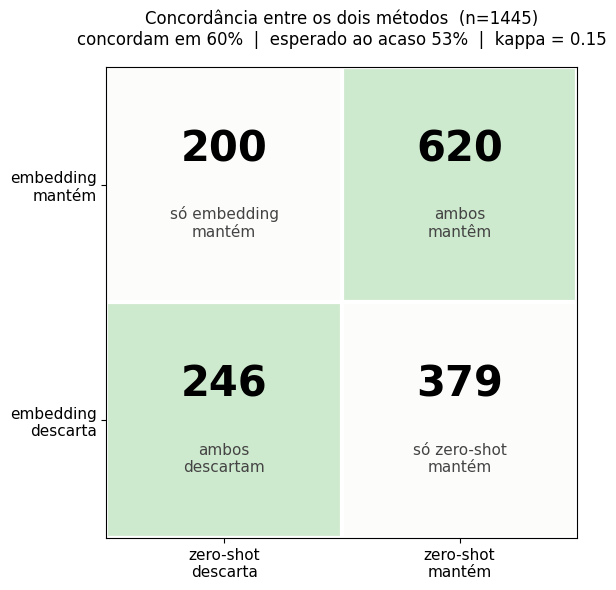

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ct = pd.crosstab(corpus["included"], corpus["included_zeroshot"])
n = ct.values.sum()
both_in  = ct.loc[1, 1]; both_out = ct.loc[0, 0]
emb_only = ct.loc[1, 0]; zs_only  = ct.loc[0, 1]

po = (both_in + both_out) / n
pe = ((ct.loc[1].sum()/n) * (ct[1].sum()/n)) + ((ct.loc[0].sum()/n) * (ct[0].sum()/n))
kappa = (po - pe) / (1 - pe)

fig, ax = plt.subplots(figsize=(7, 6))
M = np.array([[emb_only, both_in], [both_out, zs_only]])
agree = np.array([[0, 1], [1, 0]])          # 1 = concordam
ax.imshow(agree, cmap="Greens", vmin=0, vmax=2, alpha=.35)

labels = [["só embedding\nmantém", "ambos\nmantêm"],
          ["ambos\ndescartam", "só zero-shot\nmantém"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i - .10, f"{M[i, j]}", ha="center", fontsize=30, weight="bold")
        ax.text(j, i + .22, labels[i][j], ha="center", fontsize=11, color="#444")

ax.set_xticks([0, 1], ["zero-shot\ndescarta", "zero-shot\nmantém"], fontsize=11)
ax.set_yticks([0, 1], ["embedding\nmantém", "embedding\ndescarta"], fontsize=11)
ax.set_title(f"Concordância entre os dois métodos  (n={n})\n"
             f"concordam em {po:.0%}  |  esperado ao acaso {pe:.0%}  |  kappa = {kappa:.2f}",
             fontsize=12, pad=16)
ax.set_xticks(np.arange(-.5, 2), minor=True)
ax.set_yticks(np.arange(-.5, 2), minor=True)
ax.grid(which="minor", color="white", linewidth=3)
ax.tick_params(which="minor", length=0)
plt.tight_layout(); plt.show()